# K-Nearest Neighbours

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

## Import Data

In [17]:
# Reading data
X_train = pd.read_csv('../data/processed/X_train_temporal_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_temporal_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_temporal_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_temporal_obj1.csv')

## Create and train the model

In [18]:
# Create the model
model = KNeighborsClassifier()

# Train the model
model.fit(X_train, y_train.values.ravel())

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Predictions

In [19]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Probabilidad de clase 1

In [29]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [38]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.5043644828087872,
 0.5266673767822634,
 0.5338896772999321,
 0.5302539354245662,
 0.5023173319531259)

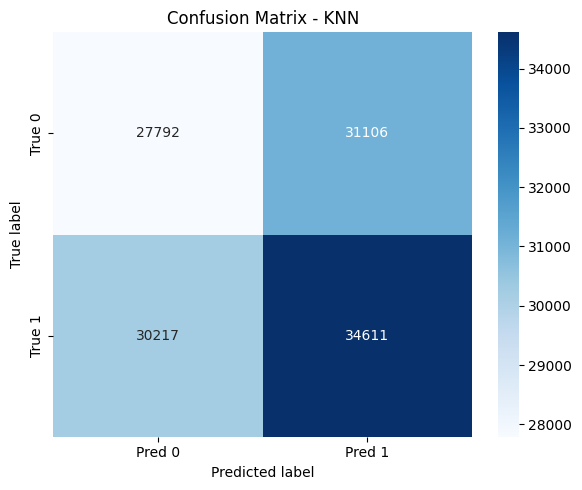

In [ ]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt="d", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])

plt.title("Confusion Matrix - KNN")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [ ]:
# Classification report
classification_report(y_test, y_pred, digits=3)

'              precision    recall  f1-score   support\n\n           0      0.479     0.472     0.475     58898\n           1      0.527     0.534     0.530     64828\n\n    accuracy                          0.504    123726\n   macro avg      0.503     0.503     0.503    123726\nweighted avg      0.504     0.504     0.504    123726\n'

## Optimization

In [ ]:
# Hyperparameters to test
hyperparameters = {"n_neighbors": [3, 5, 7, 9, 11, 13],
                   "weights": ["uniform", "distance"],
                   "metric": ["euclidean", "manhattan", "minkowski"]}

# Time Series Split for cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(KNeighborsClassifier(), hyperparameters, scoring="roc_auc", cv=tscv, n_jobs=-1)

In [40]:
# Train Grid Search
grid_search.fit(X_train, y_train.values.ravel())

# Looking for best parameters
grid_search.best_params_

KeyboardInterrupt: 

In [24]:
# Evaluate optimized model on the test set
grid_model = grid_search.best_estimator_
test_accuracy = grid_model.score(X_test, y_test)
y_pred_grid = grid_model.predict(X_test)
y_proba_grid = grid_model.predict_proba(X_test)[:, 1]

In [25]:
# Metrics for optimized model
test_precision = precision_score(y_test, y_pred_grid)
test_recall = recall_score(y_test, y_pred_grid)
test_f1 = f1_score(y_test, y_pred_grid)
test_roc_auc = roc_auc_score(y_test, y_proba_grid)
test_cm = confusion_matrix(y_test, y_pred_grid)
test_report = classification_report(y_test, y_pred_grid)

In [ ]:
# Showing results
test_precision, test_recall, test_f1, test_roc_auc

Optimized KNN Test Accuracy: 0.5054475211354121
Precision: 0.5269527604544714
Recall: 0.5487289442833344
F1-score: 0.5376204329920278
ROC AUC: 0.5039774939013099
Confusion Matrix:
 [[26964 31934]
 [29255 35573]]

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.46      0.47     58898
           1       0.53      0.55      0.54     64828

    accuracy                           0.51    123726
   macro avg       0.50      0.50      0.50    123726
weighted avg       0.50      0.51      0.50    123726



### Conclusion
The K-Nearest Neighbors (KNN) model applied to the task of predicting whether a stock will increase by at least 1% on the following day shows performance close to random guessing. The obtained metrics, particularly a ROC AUC around 0.50, indicates that the model lacks real discriminative power between the classes. Despite hyperparameter optimization using time-aware cross-validation, no meaningful improvement in performance is observed. This suggests that KNN is not well suited for this financial prediction task, likely due to the high level of noise in the data and the limitations of distance-based methods in higher-dimensional feature spaces. Therefore, this model should be considered an ineffective baseline, and more robust models better suited for time-series financial data are recommended.

### Conclusión
El modelo K-Nearest Neighbors (KNN) aplicado a la predicción de si una acción subirá al menos un 1% al día siguiente muestra un rendimiento cercano al azar. Las métricas obtenidas, especialmente el ROC AUC alrededor de 0.50, indican que el modelo no tiene capacidad discriminativa real entre las clases. A pesar de la optimización de hiperparámetros mediante validación temporal, no se observan mejoras significativas en el desempeño. Esto sugiere que KNN no es un modelo adecuado para este problema de predicción financiera, probablemente debido al alto nivel de ruido de los datos y a las limitaciones del método en espacios de características de mayor dimensionalidad. Por lo tanto, el modelo se considera un baseline no efectivo, y se recomienda explorar modelos alternativos más robustos para datos temporales y financieros.